# Static/dynamic manifold dynamics

Visualize within-condition dRSA autocorrelation and PCA-subspace rotation, plus cross-temporal static-dynamic RDM similarity and PCA-subspace rotation, for the full matched stimulus set, top and bottom population-activating images, and size-matched random controls.

The notebook reads the saved result archive; it does not recompute RDMs or PCA subspaces. The `all` condition contains 100 stimuli, whereas top, bottom, and random contain 50 by default. Use the random subset as the size-matched control when interpreting top/bottom effects.

In [1]:
from dataclasses import dataclass
import csv
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config.yaml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find config.yaml above the notebook directory.")
    # end if PROJECT_ROOT.parent
    PROJECT_ROOT = PROJECT_ROOT.parent
# end while not config.yaml exists


@dataclass
class Cfg:
    static_exp_name: str = "baby1_260718to27" # "red_20260726to27" # 
    dynamic_exp_name: str =  "baby1_260716to24" #  "red_20260720to24" # 
    results_dir: str | None = None
    good_channels: tuple[int, int] | None = (84, 186) # None #
    subset_names: tuple[str, ...] = (
        "all", "top", "bottom", "random_001",
    )
    cross_subset_names: tuple[str, ...] | None = None
    max_lag_ms: float = 700
    figure_dpi: int = 140
    save_figures: bool = False
# EOF


cfg = Cfg()
"""
channel_selection_name
Build the result-folder label matching the analysis channel selection.
"""
def channel_selection_name(cfg):
    if cfg.good_channels is None:
        return "all_channels"
    # end if cfg.good_channels is None
    first_channel, last_channel = cfg.good_channels
    return f"channels_{first_channel}to{last_channel}"
# EOF

results_root = Path(
    cfg.results_dir
    or PROJECT_ROOT
    / "results"
    / "static_dynamic_manifold_dynamics"
    / f"{cfg.dynamic_exp_name}_vs_{cfg.static_exp_name}"
).expanduser()
results_dir = results_root / channel_selection_name(cfg)
# Preserve compatibility with analyses generated before channel folders.
legacy_results_dir = results_root
if not (results_dir / "manifold_dynamics_results.npz").is_file():
    if (legacy_results_dir / "manifold_dynamics_results.npz").is_file():
        results_dir = legacy_results_dir
    # end if legacy archive exists
# end if channel-specific archive is missing
results_path = results_dir / "manifold_dynamics_results.npz"
config_path = results_dir / "config.json"
summary_path = results_dir / "summary.csv"

if not results_path.is_file():
    raise FileNotFoundError(f"Missing result archive: {results_path}")
# end if results_path
cfg, results_dir

(Cfg(static_exp_name='baby1_260718to27', dynamic_exp_name='baby1_260716to24', results_dir=None, good_channels=(84, 186), subset_names=('all', 'top', 'bottom', 'random_001'), cross_subset_names=None, max_lag_ms=700, figure_dpi=140, save_figures=False),
 PosixPath('/Users/tizianocausin/Desktop/static_dynamic/results/static_dynamic_manifold_dynamics/baby1_260716to24_vs_baby1_260718to27/channels_84to186'))

In [2]:
with np.load(results_path, allow_pickle=False) as archive:
    saved_arrays = {name: archive[name] for name in archive.files}
# end with np.load

with open(config_path, "r") as file:
    analysis_config = json.load(file)
# end with open config

with open(summary_path, "r", newline="") as file:
    summary_rows = list(csv.DictReader(file))
# end with open summary

conditions = ("static", "dynamic")
for condition in conditions:
    for subset_name in cfg.subset_names:
        expected_key = f"{condition}__{subset_name}__drsa_autocorrelation"
        if expected_key not in saved_arrays:
            raise KeyError(f"Missing configured subset result: {expected_key}")
        # end if expected_key
    # end for subset_name
# end for condition

print(f"Results: {results_dir}")
print(f"Matched stimuli: {len(saved_arrays['shared_stimuli'])}")
print(f"Channels: {analysis_config['good_channels'] or 'all available'}")
print(f"Analysis sampling rate: {analysis_config['analysis_fs']} Hz")
print(f"Static selection window: {analysis_config['static_selection_window_ms']} ms")
print(f"Dynamic selection window: {analysis_config['dynamic_selection_window_ms']} ms")
print(f"Selection reference: {analysis_config['selection_reference']}")

Results: /Users/tizianocausin/Desktop/static_dynamic/results/static_dynamic_manifold_dynamics/baby1_260716to24_vs_baby1_260718to27/channels_84to186
Matched stimuli: 100
Channels: [84, 186]
Analysis sampling rate: 100 Hz
Static selection window: [60, 200] ms
Dynamic selection window: [2560, 2700] ms
Selection reference: condition


In [3]:
"""
finish_figure
Optionally save a visualization beside the numerical results and display it.

INPUT:
    - figure: matplotlib.figure.Figure -> completed figure
    - filename: str -> output filename used when saving is enabled
"""
def finish_figure(figure, filename):
    if cfg.save_figures:
        figure.savefig(
            results_dir / filename, dpi=cfg.figure_dpi, bbox_inches="tight",
        )
    # end if save_figures
    plt.show()
# EOF


"""
plot_matrix_grid
Plot one saved time-by-time matrix for all configured subsets and conditions.

INPUT:
    - matrix_name: str -> saved matrix suffix
    - title: str -> figure title
    - colorbar_label: str -> color scale label
    - cmap: str -> Matplotlib color map
    - vmin: float -> lower color bound
    - vmax: float -> upper color bound
"""
def plot_matrix_grid(
        matrix_name, title, colorbar_label, cmap, vmin, vmax,
        ):
    figure, axes = plt.subplots(
        2, len(cfg.subset_names),
        figsize=(4.1 * len(cfg.subset_names), 7.2),
        squeeze=False, constrained_layout=True,
    )
    image = None
    for row_index, condition in enumerate(conditions):
        times_ms = saved_arrays[f"{condition}__times_ms"]
        extent = (times_ms[0], times_ms[-1], times_ms[0], times_ms[-1])
        for column_index, subset_name in enumerate(cfg.subset_names):
            matrix = saved_arrays[
                f"{condition}__{subset_name}__{matrix_name}"
            ]
            image = axes[row_index, column_index].imshow(
                matrix, origin="lower", aspect="auto", extent=extent,
                cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest",
            )
            axes[row_index, column_index].set(
                xlabel="Time (ms)", ylabel="Time (ms)",
                title=f"{condition.title()} - {subset_name}",
            )
        # end for column_index, subset_name
    # end for row_index, condition
    figure.suptitle(title, fontsize=15, y=1.035)
    figure.colorbar(
        image, ax=axes, label=colorbar_label, shrink=0.86, pad=0.02,
    )
    finish_figure(figure, f"notebook_{matrix_name}.png")
# EOF

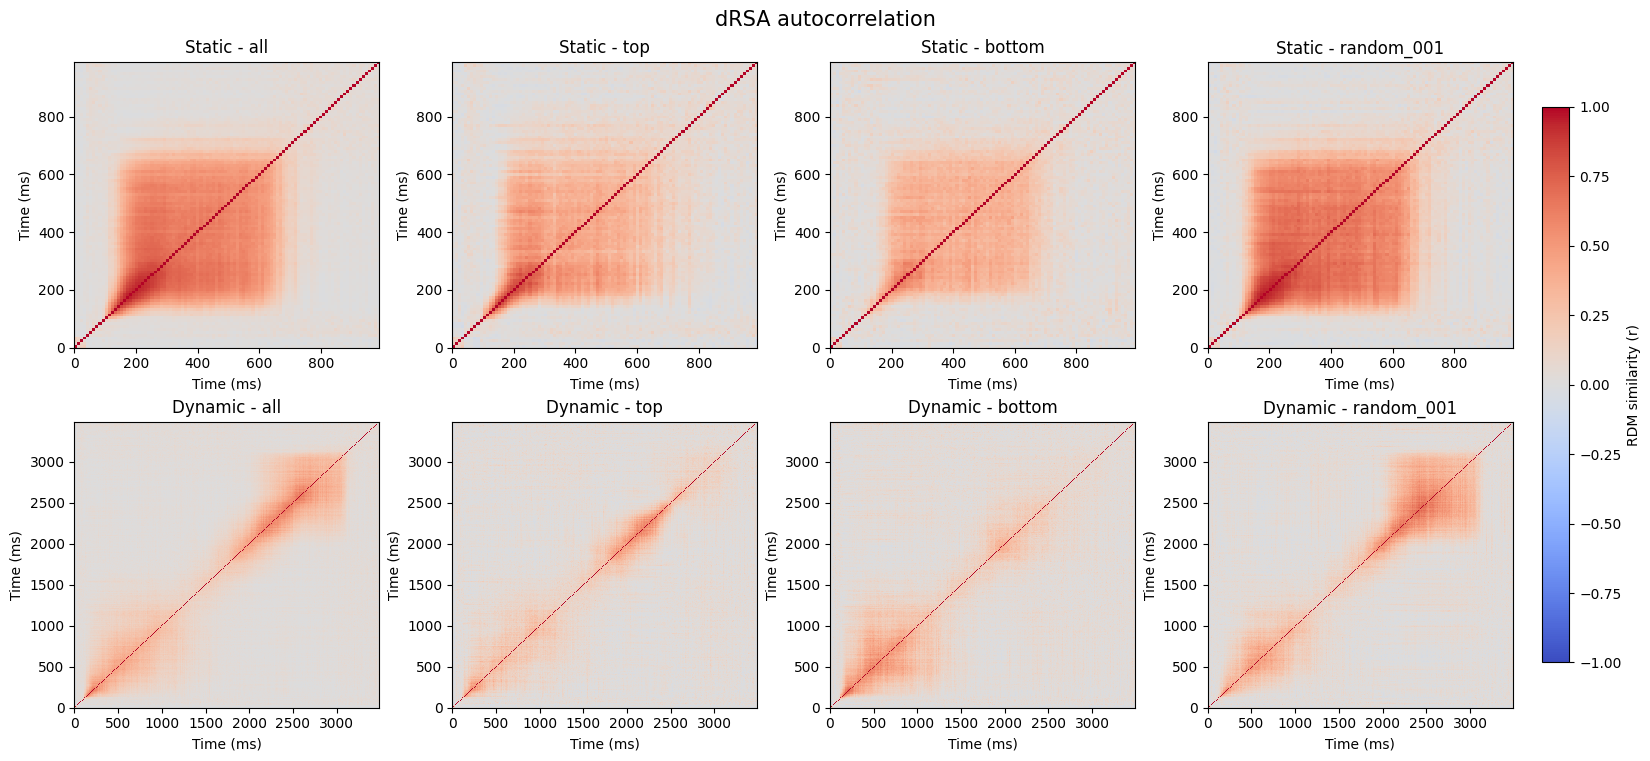

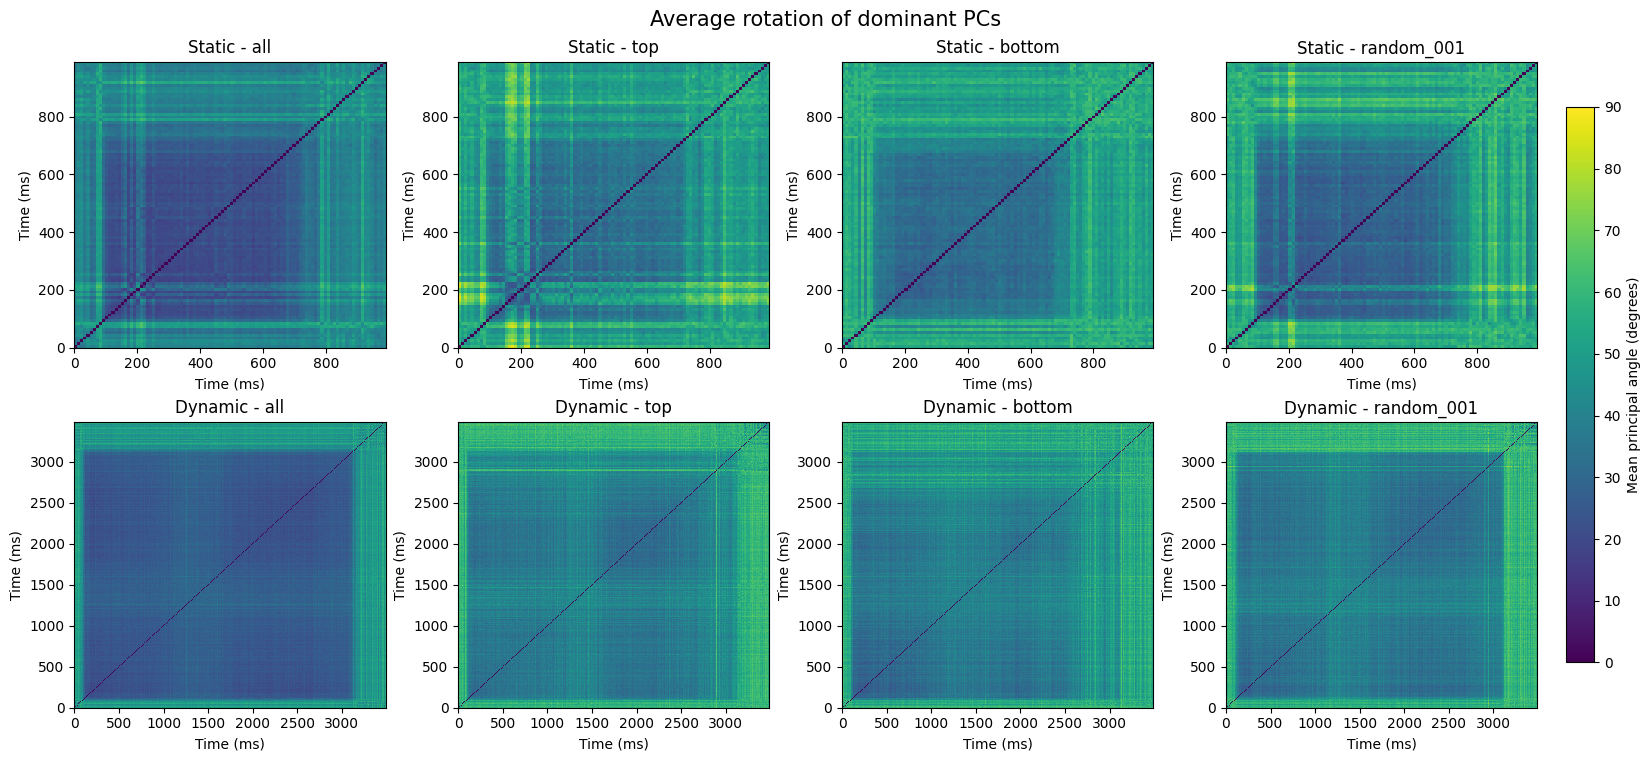

In [4]:
plot_matrix_grid(
    "drsa_autocorrelation",
    "dRSA autocorrelation",
    "RDM similarity (r)",
    "coolwarm", -1, 1,
)

plot_matrix_grid(
    "pc_rotation_degrees",
    "Average rotation of dominant PCs",
    "Mean principal angle (degrees)",
    "viridis", 0, 90,
)

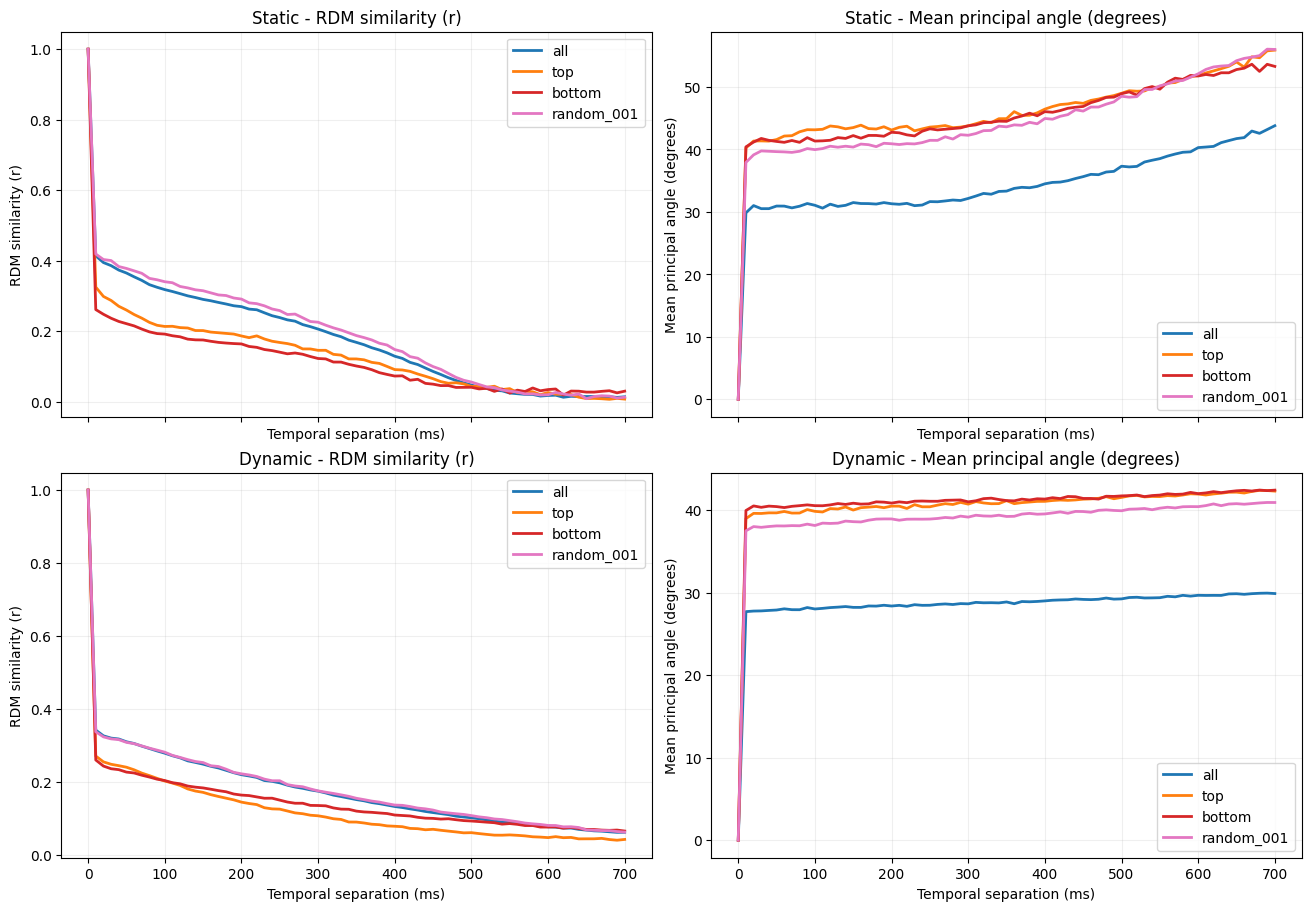

In [5]:
"""
matrix_lag_curve
Average diagonals of a square time-by-time matrix at non-negative lags.

INPUT:
    - matrix: np.ndarray -> square time-by-time analysis matrix
    - fs: float -> matrix sampling frequency in Hz
    - max_lag_ms: float -> largest temporal separation to summarize

OUTPUT:
    - lag_times_ms: np.ndarray -> non-negative lag coordinates
    - lag_values: np.ndarray -> mean matrix value at every lag
"""
def matrix_lag_curve(matrix, fs, max_lag_ms):
    maximum_lag = min(
        int(round(max_lag_ms * fs / 1000)), matrix.shape[0] - 1,
    )
    lag_samples = np.arange(maximum_lag + 1)
    lag_values = np.asarray([
        np.nanmean(np.diag(matrix, k=lag)) for lag in lag_samples
    ])
    return lag_samples * 1000 / fs, lag_values
# EOF


analysis_fs = float(analysis_config["analysis_fs"])
figure, axes = plt.subplots(
    2, 2, figsize=(13, 9), sharex="col", constrained_layout=True,
)
matrix_specs = (
    ("drsa_autocorrelation", "RDM similarity (r)"),
    ("pc_rotation_degrees", "Mean principal angle (degrees)"),
)
subset_colors = dict(
    zip(cfg.subset_names, plt.cm.tab10(np.linspace(0, 0.6, len(cfg.subset_names))))
)
for row_index, condition in enumerate(conditions):
    for column_index, (matrix_name, ylabel) in enumerate(matrix_specs):
        axis = axes[row_index, column_index]
        for subset_name in cfg.subset_names:
            matrix = saved_arrays[
                f"{condition}__{subset_name}__{matrix_name}"
            ]
            lag_times_ms, lag_values = matrix_lag_curve(
                matrix, analysis_fs, cfg.max_lag_ms,
            )
            axis.plot(
                lag_times_ms, lag_values, label=subset_name,
                color=subset_colors[subset_name], linewidth=2,
            )
        # end for subset_name
        axis.set(
            xlabel="Temporal separation (ms)", ylabel=ylabel,
            title=f"{condition.title()} - {ylabel}",
        )
        axis.grid(alpha=0.2)
        axis.legend()
    # end for column_index, matrix spec
# end for row_index, condition
finish_figure(figure, "notebook_lag_curves.png")

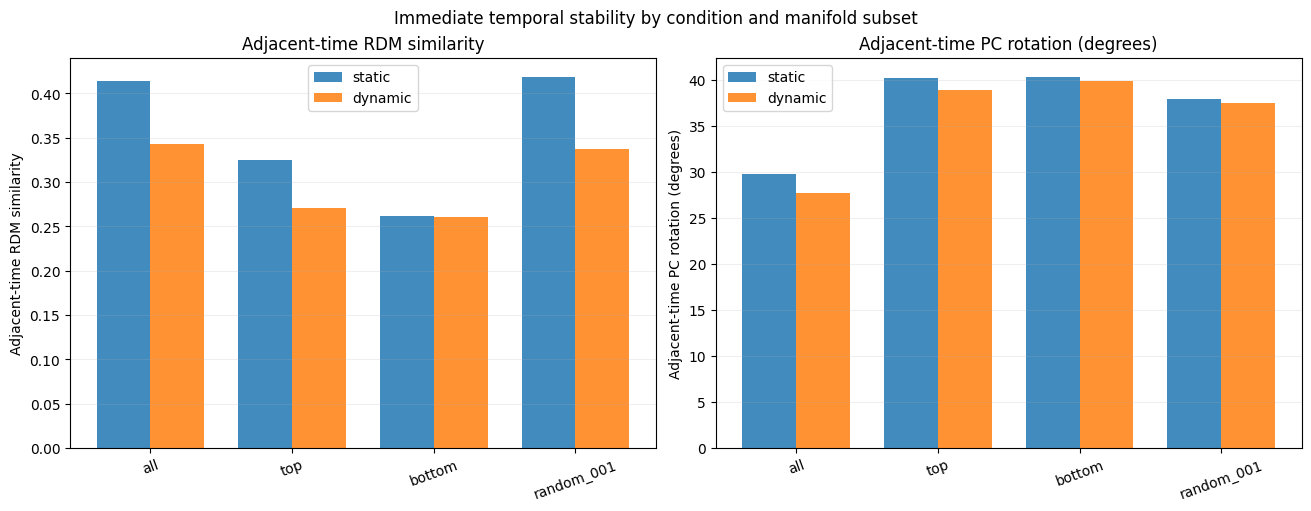

In [6]:
summary_lookup = {
    (row["condition"], row["subset"]): row
    for row in summary_rows
}
bar_specs = (
    ("drsa_adjacent", "Adjacent-time RDM similarity"),
    ("rotation_adjacent_degrees", "Adjacent-time PC rotation (degrees)"),
)
figure, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
x_positions = np.arange(len(cfg.subset_names))
bar_width = 0.38
for axis, (value_name, ylabel) in zip(axes, bar_specs):
    for condition_index, condition in enumerate(conditions):
        values = [
            float(summary_lookup[(condition, subset_name)][value_name])
            for subset_name in cfg.subset_names
        ]
        offset = (condition_index - 0.5) * bar_width
        axis.bar(
            x_positions + offset, values, width=bar_width,
            label=condition, alpha=0.85,
        )
    # end for condition_index, condition
    axis.set(
        xticks=x_positions, xticklabels=cfg.subset_names,
        ylabel=ylabel, title=ylabel,
    )
    axis.tick_params(axis="x", rotation=20)
    axis.grid(axis="y", alpha=0.2)
    axis.legend()
# end for axis, bar spec
figure.suptitle(
    "Immediate temporal stability by condition and manifold subset"
)
finish_figure(figure, "notebook_adjacent_summary.png")

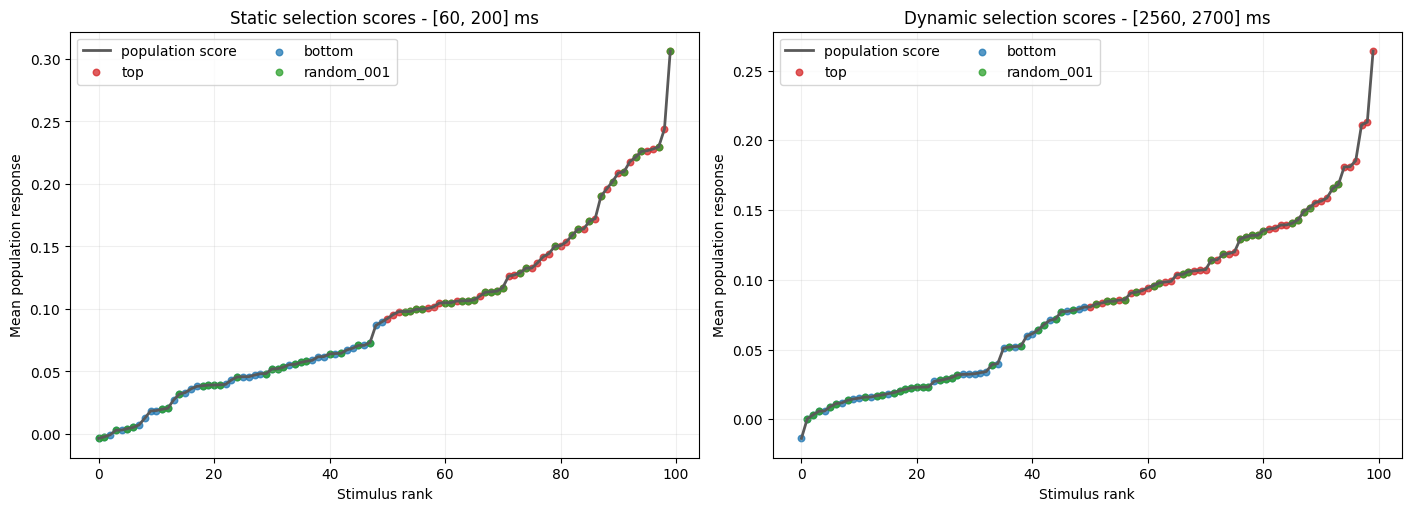

top: 41 shared stimuli; Jaccard=0.695
bottom: 41 shared stimuli; Jaccard=0.695
random_001: 50 shared stimuli; Jaccard=1.000


In [7]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for axis, condition in zip(axes, conditions):
    scores = saved_arrays[f"{condition}__population_scores"]
    stimulus_order = np.argsort(scores)
    axis.plot(
        np.arange(len(scores)), scores[stimulus_order],
        color="0.35", linewidth=2, label="population score",
    )
    for subset_name, color in (
            ("top", "tab:red"), ("bottom", "tab:blue"),
            ("random_001", "tab:green"),
            ):
        selected_indices = saved_arrays[
            f"{condition}__{subset_name}__indices"
        ]
        selected_mask = np.isin(stimulus_order, selected_indices)
        axis.scatter(
            np.flatnonzero(selected_mask), scores[stimulus_order][selected_mask],
            s=22, color=color, alpha=0.75, label=subset_name,
        )
    # end for subset_name, color
    axis.set(
        xlabel="Stimulus rank", ylabel="Mean population response",
        title=(
            f"{condition.title()} selection scores - "
            f"{analysis_config[condition + '_selection_window_ms']} ms"
        ),
    )
    axis.grid(alpha=0.2)
    axis.legend(ncol=2)
# end for axis, condition
finish_figure(figure, "notebook_selection_scores.png")

for subset_name in ("top", "bottom", "random_001"):
    static_indices = set(saved_arrays[f"static__{subset_name}__indices"].tolist())
    dynamic_indices = set(saved_arrays[f"dynamic__{subset_name}__indices"].tolist())
    overlap = len(static_indices & dynamic_indices)
    union = len(static_indices | dynamic_indices)
    print(
        f"{subset_name}: {overlap} shared stimuli; Jaccard={overlap / union:.3f}"
    )
# end for subset_name

Cross-temporal subsets: ('all', 'static_top', 'dynamic_top', 'static_bottom', 'dynamic_bottom', 'random_001')


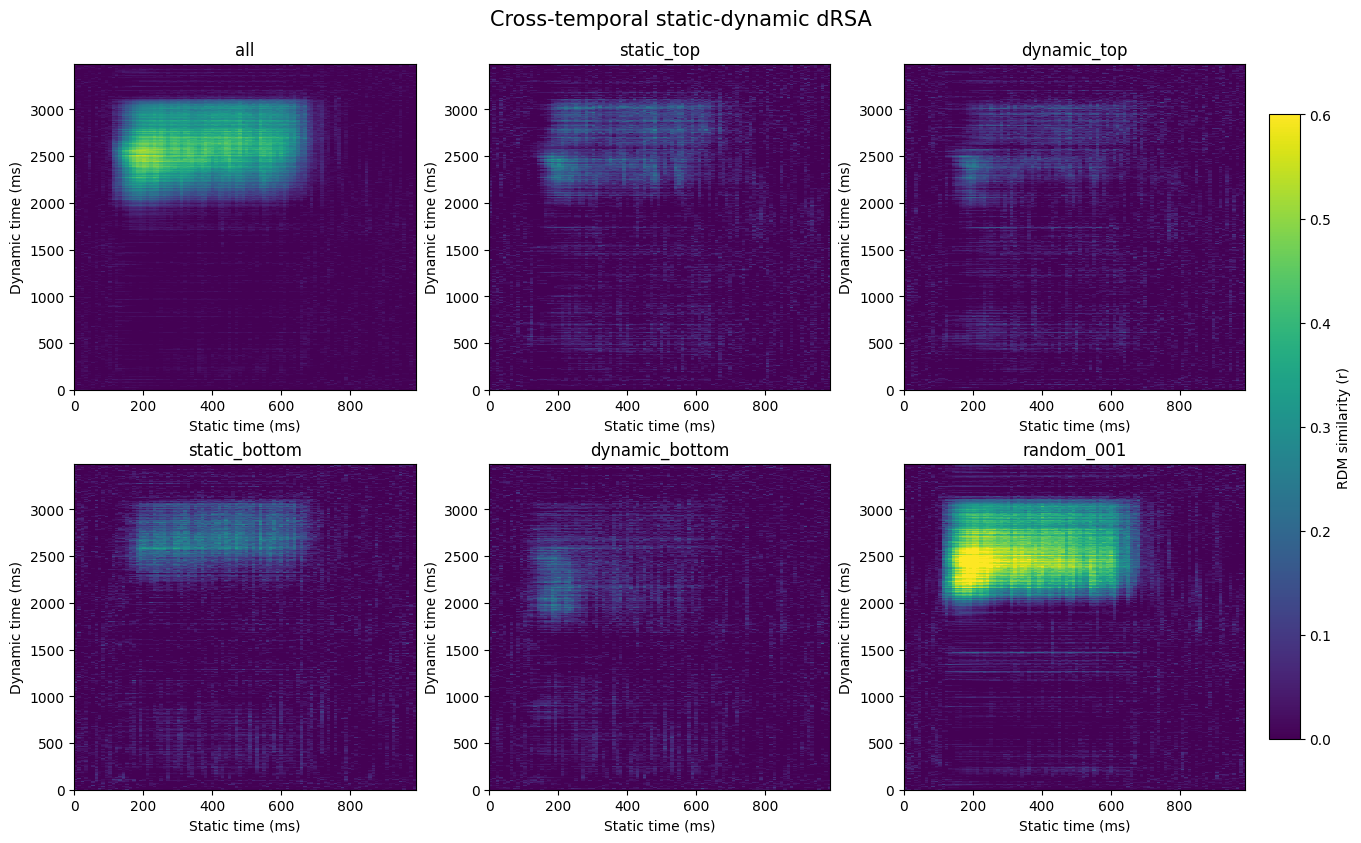

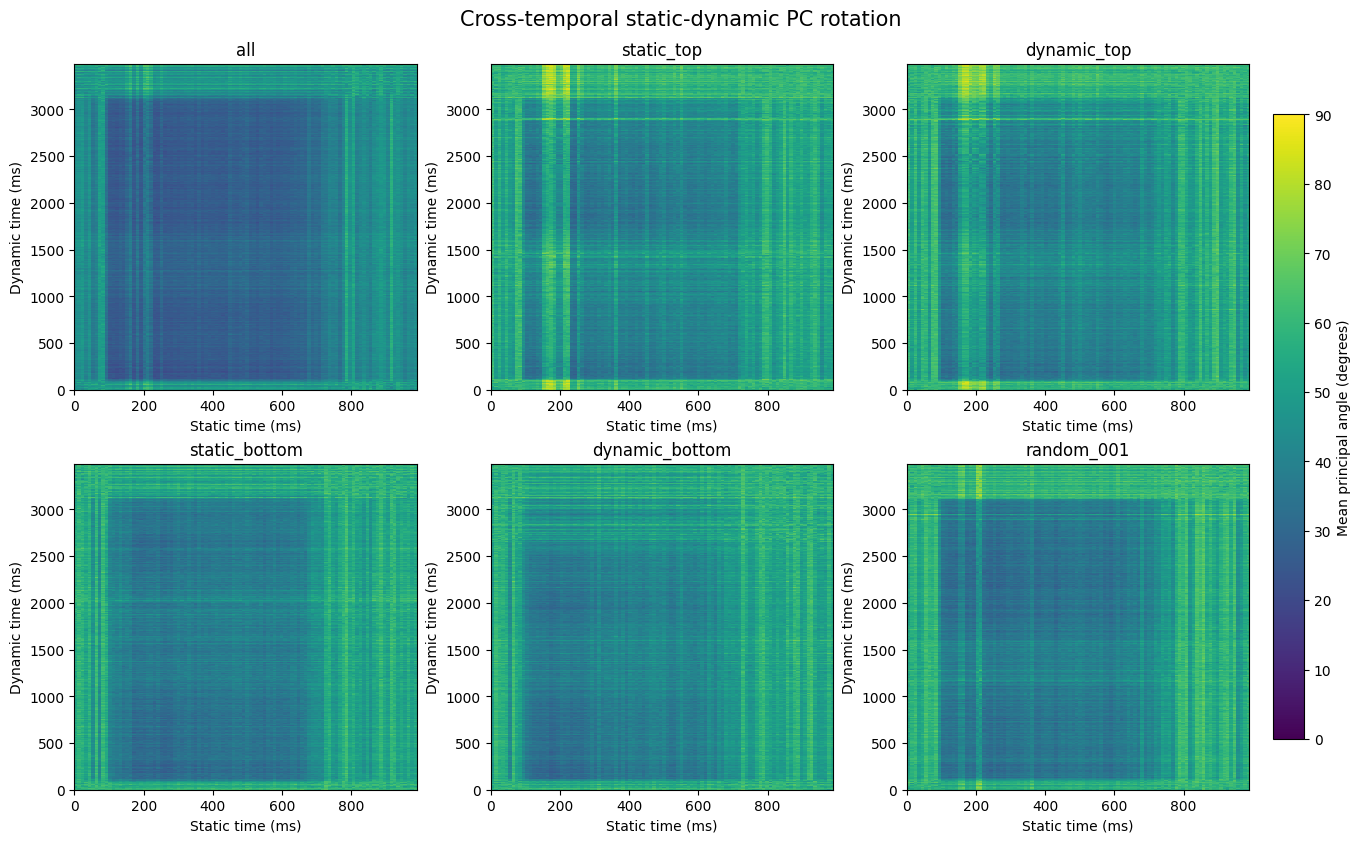

In [8]:
cross_prefix = "cross_temporal__"
cross_suffix = "__drsa_similarity"
available_cross_subsets = tuple(
    key[len(cross_prefix):-len(cross_suffix)]
    for key in saved_arrays
    if key.startswith(cross_prefix) and key.endswith(cross_suffix)
)
cross_subset_names = (
    available_cross_subsets
    if cfg.cross_subset_names is None
    else cfg.cross_subset_names
)
missing_cross_subsets = set(cross_subset_names) - set(available_cross_subsets)
if missing_cross_subsets:
    raise KeyError(
        f"Missing configured cross-temporal subsets: "
        f"{sorted(missing_cross_subsets)}"
    )
# end if missing_cross_subsets


"""
plot_cross_temporal_matrix_grid
Plot one dynamic-time by static-time matrix for all shared subsets.

INPUT:
    - matrix_name: str -> saved cross-temporal matrix suffix
    - title: str -> figure title
    - colorbar_label: str -> color scale label
    - cmap: str -> Matplotlib color map
    - vmin: float -> lower color bound
    - vmax: float -> upper color bound
"""
def plot_cross_temporal_matrix_grid(
        matrix_name, title, colorbar_label, cmap, vmin, vmax,
        ):
    n_columns = min(3, len(cross_subset_names))
    n_rows = int(np.ceil(len(cross_subset_names) / n_columns))
    figure, axes = plt.subplots(
        n_rows, n_columns, figsize=(4.5 * n_columns, 4 * n_rows),
        squeeze=False, constrained_layout=True,
    )
    static_times_ms = saved_arrays["static__times_ms"]
    dynamic_times_ms = saved_arrays["dynamic__times_ms"]
    extent = (
        static_times_ms[0], static_times_ms[-1],
        dynamic_times_ms[0], dynamic_times_ms[-1],
    )
    image = None
    for subset_index, subset_name in enumerate(cross_subset_names):
        row_index, column_index = divmod(subset_index, n_columns)
        axis = axes[row_index, column_index]
        matrix = saved_arrays[
            f"cross_temporal__{subset_name}__{matrix_name}"
        ]
        image = axis.imshow(
            matrix, origin="lower", aspect="auto", extent=extent,
            cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest",
        )
        axis.set(
            xlabel="Static time (ms)", ylabel="Dynamic time (ms)",
            title=subset_name,
        )
    # end for subset_index, subset_name
    for empty_index in range(
            len(cross_subset_names), n_rows * n_columns,
            ):
        row_index, column_index = divmod(empty_index, n_columns)
        axes[row_index, column_index].set_visible(False)
    # end for empty_index
    figure.suptitle(title, fontsize=15, y=1.035)
    figure.colorbar(
        image, ax=axes, label=colorbar_label, shrink=0.86, pad=0.02,
    )
    finish_figure(figure, f"notebook_cross_temporal_{matrix_name}.png")
# EOF


if cross_subset_names:
    print(f"Cross-temporal subsets: {cross_subset_names}")
    plot_cross_temporal_matrix_grid(
        "drsa_similarity",
        "Cross-temporal static-dynamic dRSA",
        "RDM similarity (r)",
        "viridis", 0, .6,
    )
    plot_cross_temporal_matrix_grid(
        "pc_rotation_degrees",
        "Cross-temporal static-dynamic PC rotation",
        "Mean principal angle (degrees)",
        "viridis", 0, 90,
    )
else:
    print(
        "No cross-temporal arrays found. Rerun "
        "run_static_dynamic_manifold_dynamics.py with --cross_temporal."
    )
# end if cross_subset_names

## Switching datasets

To visualize Red instead, set `static_exp_name="red_20260726to27"` and `dynamic_exp_name="red_20260720to24"` in `Cfg`, then rerun the notebook. Set `save_figures=True` to write the notebook-specific figures beside the numerical result archive.

Cross-temporal computation is enabled by default in `run_static_dynamic_manifold_dynamics.py`. Use `--no-cross_temporal` to skip it. With `selection_reference="condition"`, cross-temporal top/bottom results are labeled `static_top`, `dynamic_top`, `static_bottom`, and `dynamic_bottom`; every label identifies the condition used to rank a shared set of stimuli that is then applied to both recordings.